Importo le librerie fondamentali

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
dfWinter = pd.read_csv('winter.csv')
dfDictionary = pd.read_csv('dictionary.csv')

In [7]:
dfWinter.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5770 entries, 0 to 5769
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Year        5770 non-null   int64 
 1   City        5770 non-null   object
 2   Sport       5770 non-null   object
 3   Discipline  5770 non-null   object
 4   Athlete     5770 non-null   object
 5   Country     5770 non-null   object
 6   Gender      5770 non-null   object
 7   Event       5770 non-null   object
 8   Medal       5770 non-null   object
dtypes: int64(1), object(8)
memory usage: 405.8+ KB


In [53]:
dfWinter.head(20)

,Year,City,Sport,Discipline,Athlete,Country,Gender,Event,Medal
0,1924,Chamonix,Biathlon,Biathlon,"BERTHET, G.",FRA,Men,Military Patrol,Bronze
1,1924,Chamonix,Biathlon,Biathlon,"MANDRILLON, C.",FRA,Men,Military Patrol,Bronze
2,1924,Chamonix,Biathlon,Biathlon,"MANDRILLON, Maurice",FRA,Men,Military Patrol,Bronze
3,1924,Chamonix,Biathlon,Biathlon,"VANDELLE, André",FRA,Men,Military Patrol,Bronze
4,1924,Chamonix,Biathlon,Biathlon,"AUFDENBLATTEN, Adolf",SUI,Men,Military Patrol,Gold
5,1924,Chamonix,Biathlon,Biathlon,"JULEN, Alphonse",SUI,Men,Military Patrol,Gold
6,1924,Chamonix,Biathlon,Biathlon,"JULEN, Ant.",SUI,Men,Military Patrol,Gold
7,1924,Chamonix,Biathlon,Biathlon,"VAUCHER, D.",SUI,Men,Military Patrol,Gold
8,1924,Chamonix,Biathlon,Biathlon,"BREMER, V.E.",FIN,Men,Military Patrol,Silver
9,1924,Chamonix,Biathlon,Biathlon,"ESKELINEN, A.",FIN,Men,Military Patrol,Silver


la prima cosa che mi viene in mente è che disciplina e il nome del atleta è irrilevante quindi li elimino

In [43]:
dfWinter = dfWinter.drop(['Event'], axis=1)

In [54]:
dfWinter.describe()

,Year
count,5770.000000
mean,1986.350433
std,24.263673
min,1924.000000
25%,1972.000000
50%,1994.000000
75%,2006.000000
max,2014.000000


Il dataset è già pulito

In [55]:
dfWinter.isnull().sum()

,0
Year,0
City,0
Sport,0
Discipline,0
Athlete,0
Country,0
Gender,0
Event,0
Medal,0


In [32]:
for col in dfWinter.select_dtypes(include="object").columns:
    print(f"\nColonna: {col}")
    print(dfWinter[col].value_counts())


Colonna: City
City
Sochi                     612
Turin                     531
Vancouver                 529
Salt Lake City            481
Nagano                    447
Innsbruck                 395
Lillehammer               343
Lake Placid               334
Albertville               325
Calgary                   264
St.Moritz                 229
Sarajevo                  222
Sapporo                   200
Grenoble                  199
Cortina d'Ampezzo         150
Squaw Valley              147
Oslo                      136
Chamonix                  118
Garmisch Partenkirchen    108
Name: count, dtype: int64

Colonna: Sport
Sport
Skiing        1781
Ice Hockey    1536
Skating       1229
Bobsleigh      452
Biathlon       420
Luge           180
Curling        172
Name: count, dtype: int64

Colonna: Country
Country
USA    653
CAN    625
NOR    457
URS    440
FIN    434
SWE    433
GER    360
SUI    285
AUT    280
RUS    263
ITA    192
GDR    162
TCH    158
FRA    152
NED    122
FRG     94
K

In [33]:
for col in dfDictionary.select_dtypes(include="object").columns:
    print(f"\nColonna: {col}")
    print(dfDictionary[col].value_counts())


Colonna: Country
Country
Afghanistan        1
Albania            1
Algeria            1
American Samoa*    1
Andorra            1
                  ..
Vietnam            1
Virgin Islands*    1
Yemen              1
Zambia             1
Zimbabwe           1
Name: count, Length: 201, dtype: int64

Colonna: Code
Code
AFG    1
ALB    1
ALG    1
ASA    1
AND    1
      ..
VIE    1
ISV    1
YEM    1
ZAM    1
ZIM    1
Name: count, Length: 201, dtype: int64


In [44]:
dfWinter.nunique()

,0
Year,22
City,19
Sport,7
Country,45
Gender,2
Medal,3


In [46]:
dfDictionary.nunique()

,0
Country,201
Code,201
Population,196
GDP per Capita,176


In [47]:
dfDictionary.head()

,Country,Code,Population,GDP per Capita
0,Afghanistan,AFG,32526562.0,594.323081
1,Albania,ALB,2889167.0,3945.217582
2,Algeria,ALG,39666519.0,4206.031232
3,American Samoa*,ASA,55538.0,NaN
4,Andorra,AND,70473.0,NaN


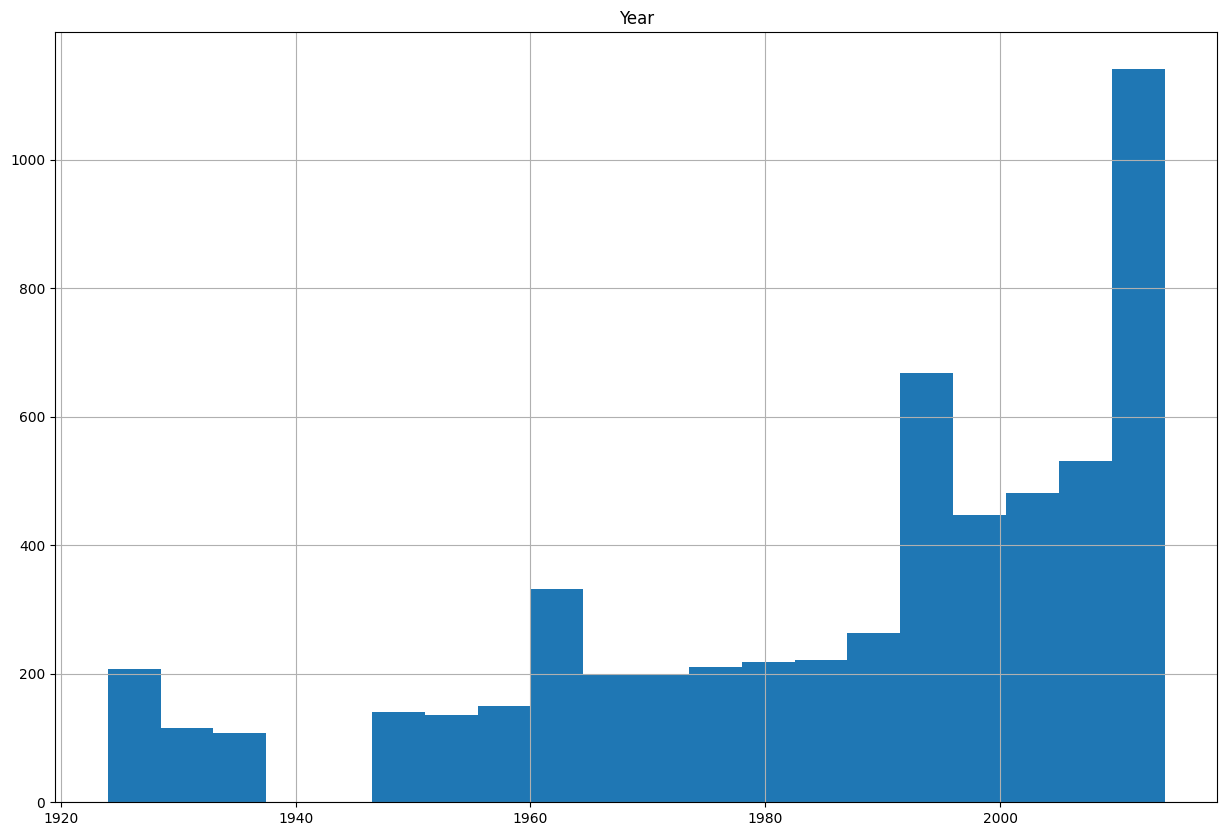

In [48]:
numerical_cols = dfWinter.select_dtypes(include=['int64','float64']).columns
dfWinter[numerical_cols].hist(figsize=(15,10), bins=20)
plt.show()


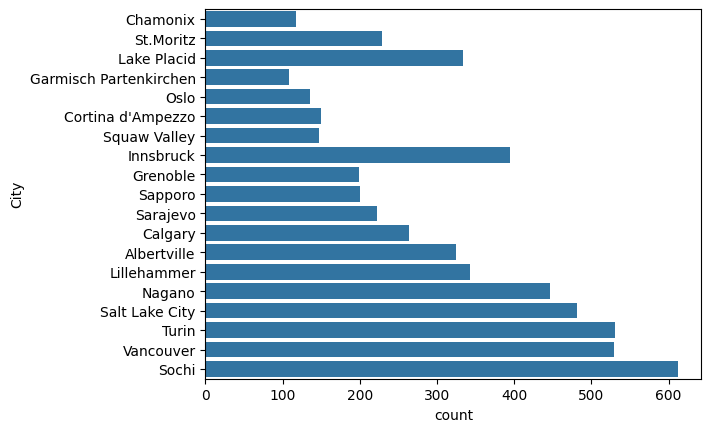

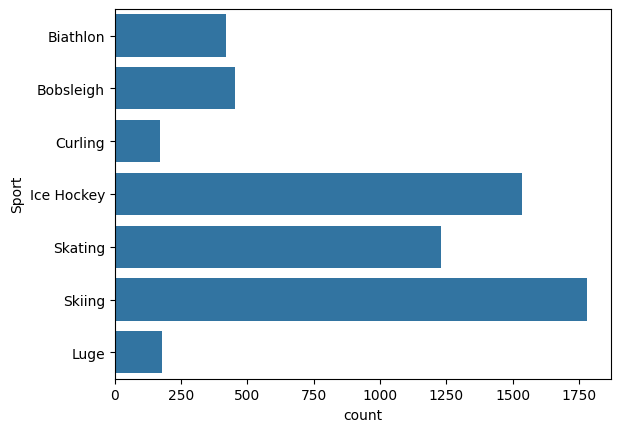

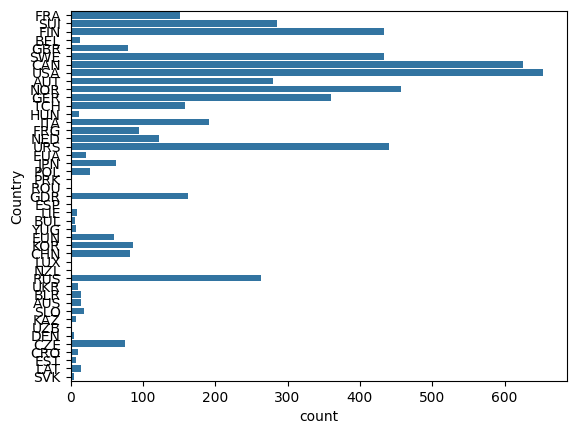

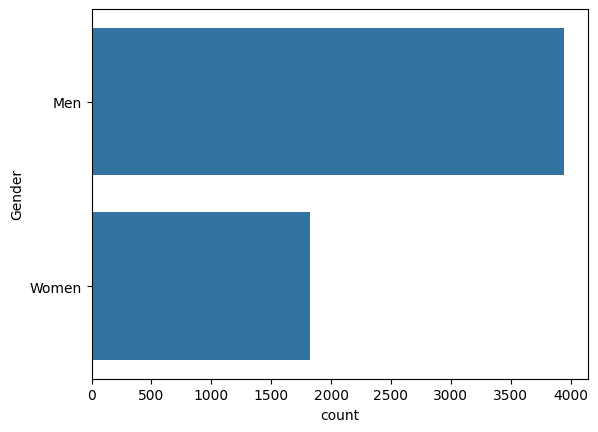

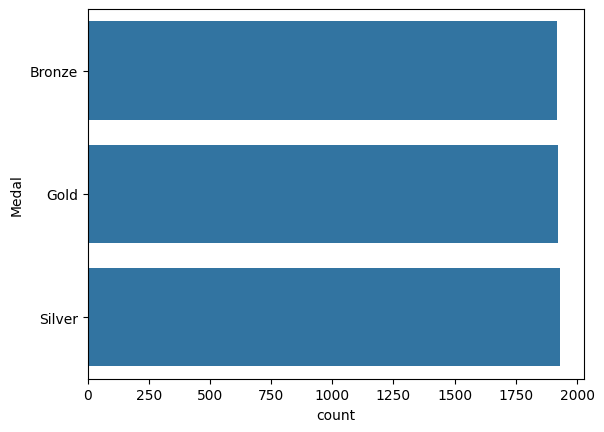

In [49]:
categorical_cols = dfWinter.select_dtypes(include=['object']).columns
for col in categorical_cols:
    sns.countplot(y=col, data=dfWinter)
    plt.show()

visualizzo i top 10 country

/tmp/ipython-input-2315709967.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette="viridis")


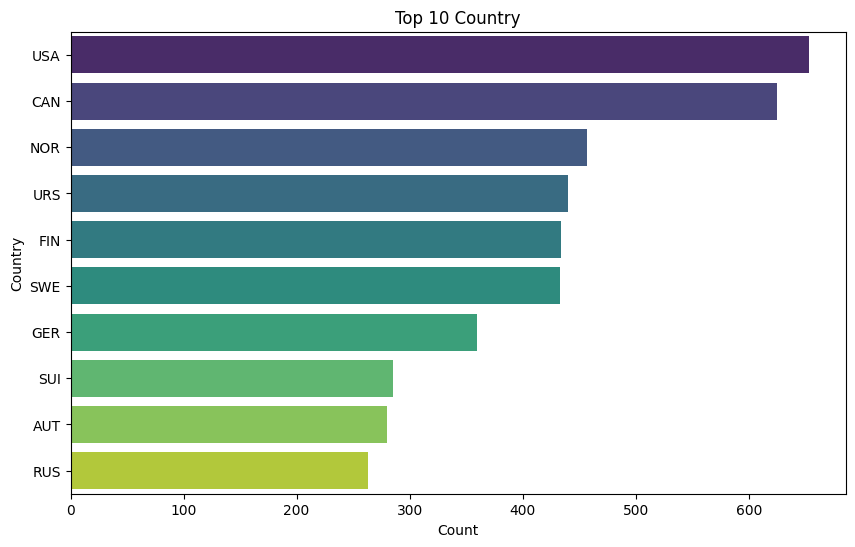

In [39]:
top_countries = dfWinter['Country'].value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_countries.values, y=top_countries.index, palette="viridis")
plt.title("Top 10 Country")
plt.xlabel("Count")
plt.ylabel("Country")
plt.show()

/tmp/ipython-input-676382888.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cities.values, y=top_cities.index, palette="magma")


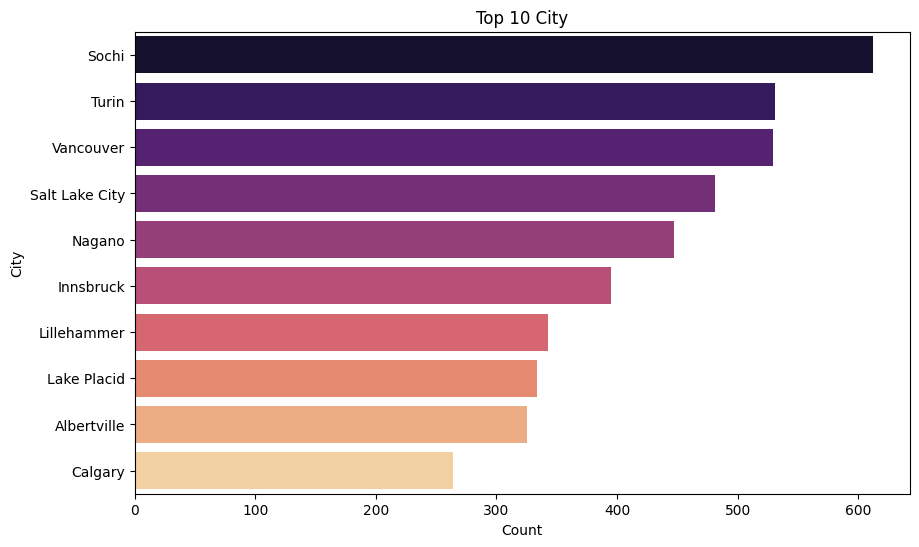

In [25]:
top_cities = dfWinter['City'].value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_cities.values, y=top_cities.index, palette="magma")
plt.title("Top 10 City")
plt.xlabel("Count")
plt.ylabel("City")
plt.show()

e la top 10 last countryes

/tmp/ipython-input-2980946764.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=last_countries.values, y=last_countries.index, palette="coolwarm")


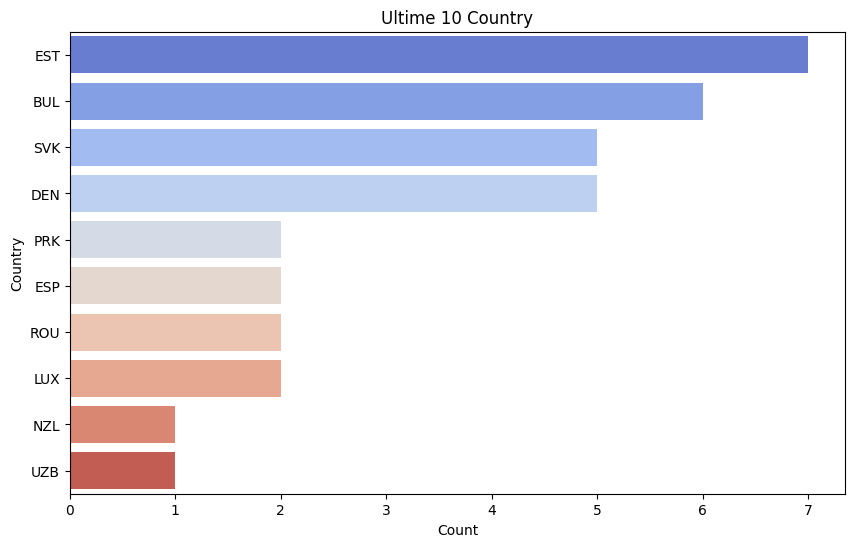

In [24]:
last_countries = dfWinter['Country'].value_counts().tail(10)
plt.figure(figsize=(10,6))
sns.barplot(x=last_countries.values, y=last_countries.index, palette="coolwarm")
plt.title("Ultime 10 Country")
plt.xlabel("Count")
plt.ylabel("Country")
plt.show()

/tmp/ipython-input-4126610912.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=last_cities.values, y=last_cities.index, palette="Spectral")


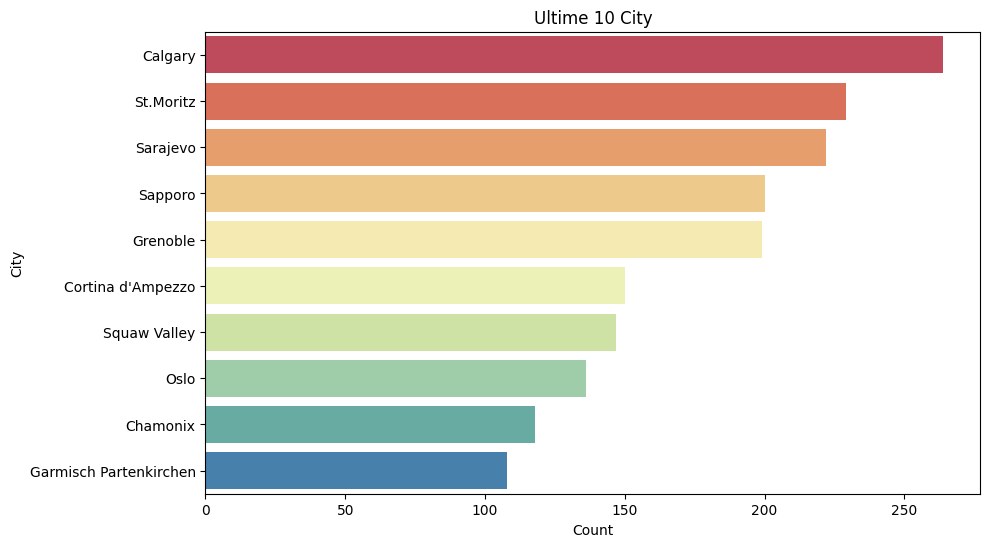

In [26]:
last_cities = dfWinter['City'].value_counts().tail(10)
plt.figure(figsize=(10,6))
sns.barplot(x=last_cities.values, y=last_cities.index, palette="Spectral")
plt.title("Ultime 10 City")
plt.xlabel("Count")
plt.ylabel("City")
plt.show()

è appurato che tutte le citta del grafico hanno comunque un buon accesso a montagne invernali dunque osservo altri fenomeni da poter correllare per capire quali sono i fattori determinante

In [50]:
# supponiamo df sia il tuo dataset originale
df = dfWinter.sort_values(['Sport', 'Country', 'Medal'])

# conta quanti atleti hanno stessa combinazione
counts = df.groupby(['Sport','Country','Medal']).size().reset_index(name='num_atleti')

# tieni solo una riga per gruppo
df_team_corrected = counts.copy()
df_team_corrected = df_team_corrected[['Sport','Country','Medal']]



In [51]:
# conteggio righe
print("Righe originali:", len(dfWinter))
print("Righe corrette:", len(df_team_corrected))

# mostra i casi aggregati
agg_test = dfWinter.groupby(['Sport','Country','Medal']).size().reset_index(name='num_atleti')
agg_test = agg_test[agg_test['num_atleti'] > 1]
print("Possibili gare a squadra (aggregati):")
print(agg_test)

Righe originali: 5770
Righe corrette: 339
Possibili gare a squadra (aggregati):
        Sport Country   Medal  num_atleti
0    Biathlon     AUT  Bronze           5
1    Biathlon     AUT  Silver           6
2    Biathlon     BLR  Bronze           3
3    Biathlon     BLR    Gold           3
4    Biathlon     BLR  Silver           2
..        ...     ...     ...         ...
332    Skiing     URS  Silver          36
333    Skiing     USA  Bronze          25
334    Skiing     USA    Gold          35
335    Skiing     USA  Silver          38
338    Skiing     YUG  Silver           6

[294 rows x 4 columns]


In [57]:
valori_event = dfWinter['Event'].unique()
print(valori_event)

['Military Patrol' 'Four-Man' 'Curling' 'Ice Hockey' 'Individual' 'Pairs'
 '10000M' '1500M' '5000M' '500M' 'Combined (4 Events)' '18KM' '50KM'
 'K90 Individual (70M)' 'Five-Man' 'Two-Man' 'Alpine Combined'
 '4X10KM Relay' 'Downhill' 'Slalom' 'Giant Slalom' '10KM' '15KM'
 '30KM Mass Start' '3X5KM Relay' '20KM' '1000M' '3000M' 'Doubles'
 'Singles' '5KM' 'K120 Individual (90M)' '4X7.5KM Relay' 'Ice Dancing'
 '4X5KM Relay' 'Super-G' 'Team' 'K120 Team (90M)' '7.5KM' '3000M Relay'
 '5000M Relay' '10KM Pursuit' '15KM Mass Start' '30KM'
 'Combined 10KM + 15KM Pursuit' 'Combined 5KM + 10KM Pursuit' 'Moguls'
 'Aerials' 'Giant-Slalom' 'Half-Pipe' '12.5Km Pursuit' '5Km Pursuit'
 'Sprint 1.5KM' 'Sprint' 'Giant Parallel Slalom' '12.5KM Mass Start'
 '4X6KM Relay' 'Team Pursuit' 'Combined 15 + 15KM Mass Start'
 'Combined 7.5 + 7.5Km Mass Start' 'Team Sprint' 'Individual Sprint'
 'Snowboard Cross' 'Super Combined' 'Ski Cross'
 'Individual, Ski Jumping K90 (70M)' 'Sprint K120' 'Team, 4X5 KM'
 'Relay Mix